In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
sns.set_context("notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Dataset Acquisition

In [2]:
# Heart Failure Clinical Records Dataset
# Public CSV mirror of the UCI dataset

dataset_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00519/heart_failure_clinical_records_dataset.csv"
)

df_original = pd.read_csv(dataset_url)

print("Dataset downloaded successfully.")
print("Shape:", df_original.shape)


Dataset downloaded successfully.
Shape: (299, 13)


## 3. Load Dataset and Display First 5 Rows

In [3]:
display(df_original.head())


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 4. Summarize Dataset

In [4]:
print("Number of rows:", df_original.shape[0])
print("Number of columns:", df_original.shape[1])

print("\nColumn names:")
print(list(df_original.columns))

print("\nData types:")
display(df_original.dtypes.to_frame("Data Type"))

print("\nMissing values in original dataset:")
display(df_original.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df_original.duplicated().sum())


Number of rows: 299
Number of columns: 13

Column names:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data types:


,Data Type
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64



Missing values in original dataset:


,Missing Values
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0



Duplicate rows: 0


### Observation
The original dataset is typically complete and contains no missing values. Since this assignment specifically requires missing-value cleaning and imputation, we create a separate working copy with a few controlled missing entries for demonstration.


## 5. Create a Working Copy with Simulated Missing Values

In [5]:
df = df_original.copy()

# Reproducibly introduce a small amount of missingness
# ONLY for demonstrating the required cleaning steps.
missing_plan = {
    "serum_creatinine": 6,
    "platelets": 5,
    "smoking": 4
}

for column, n_missing in missing_plan.items():
    chosen_idx = np.random.choice(df.index, size=n_missing, replace=False)
    df.loc[chosen_idx, column] = np.nan

print("Missing values in working copy:")
display(df.isnull().sum().to_frame("Missing Values"))


Missing values in working copy:


,Missing Values
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,5
serum_creatinine,6
serum_sodium,0
sex,0


## 6. Visualize Missing Values Using a Heatmap

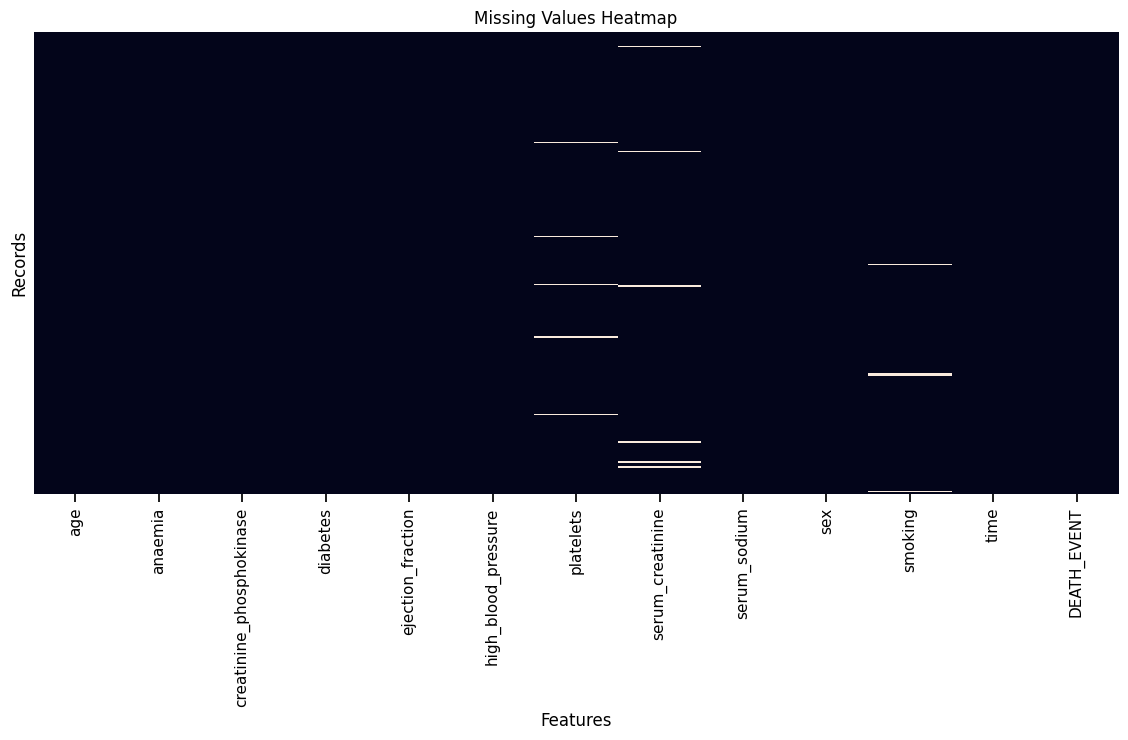

In [6]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()


## 7. Plot Distributions of Numerical Features

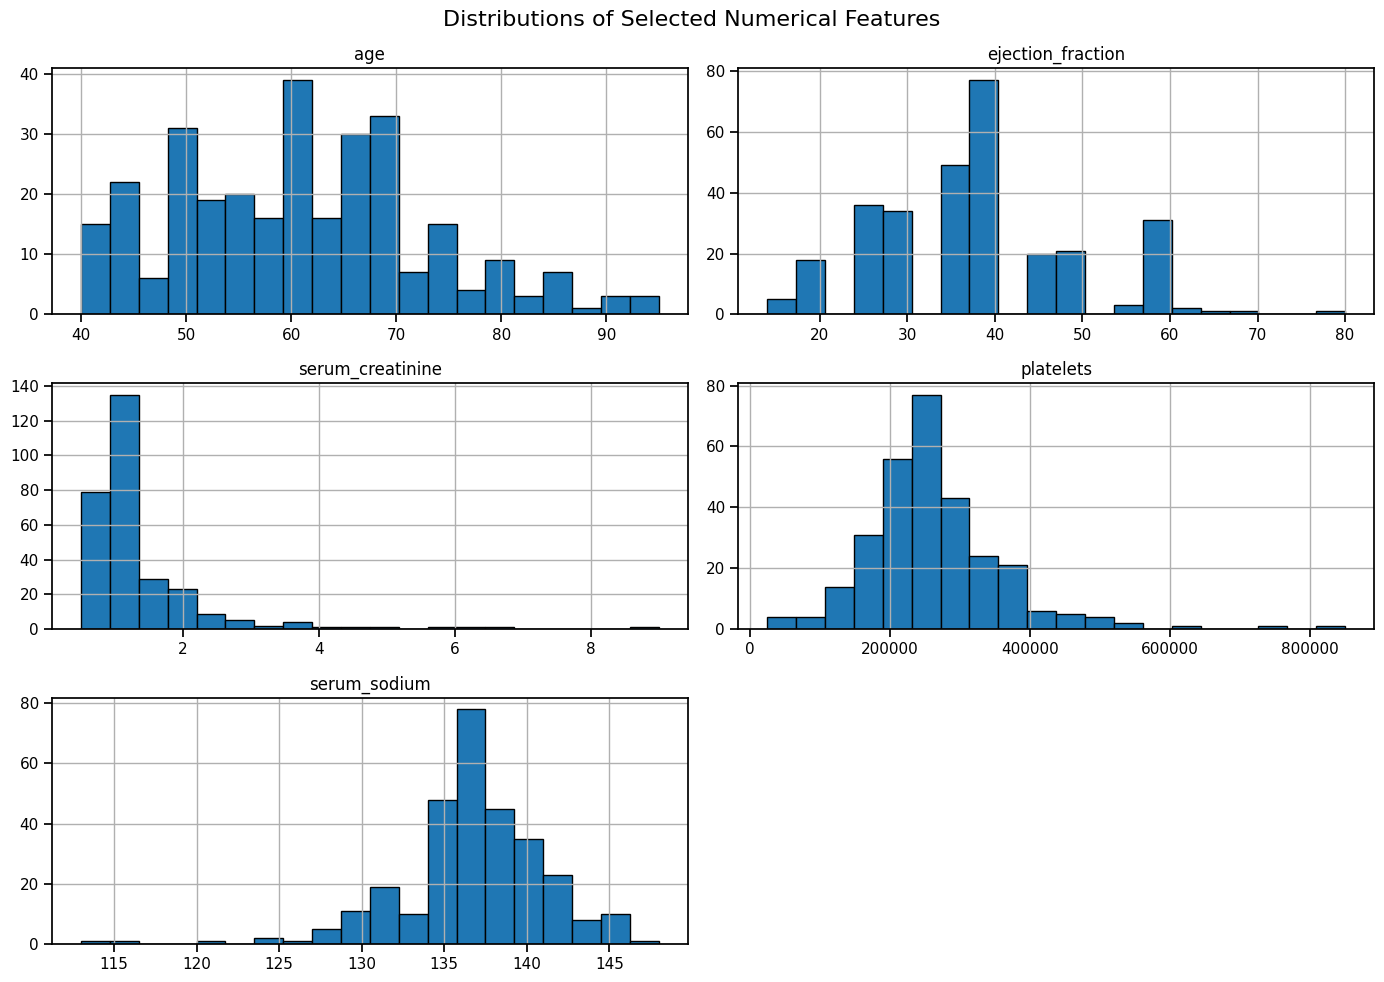

In [7]:
selected_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets",
    "serum_sodium"
]

df[selected_features].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Distributions of Selected Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


### Boxplots Before Cleaning

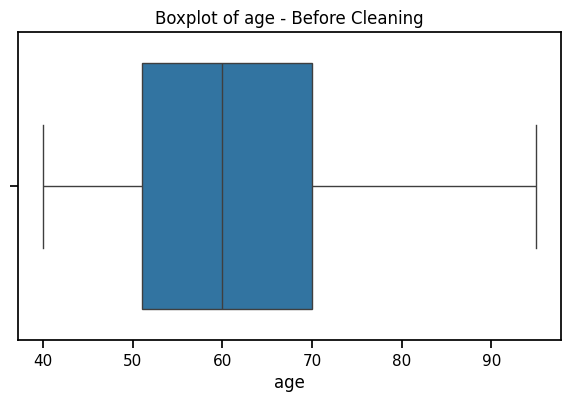

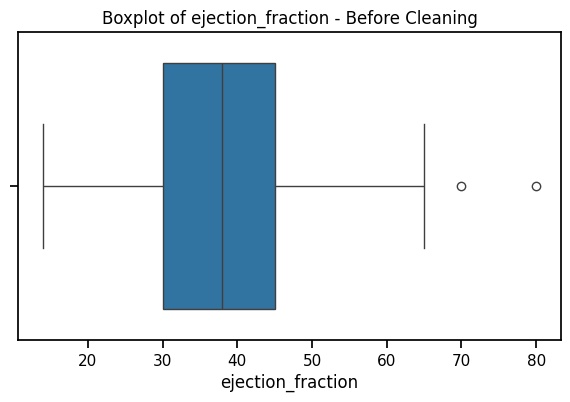

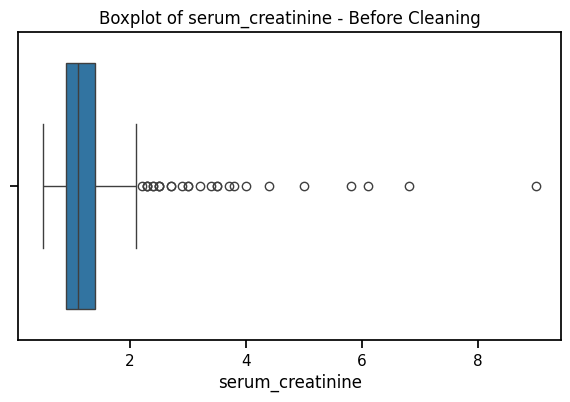

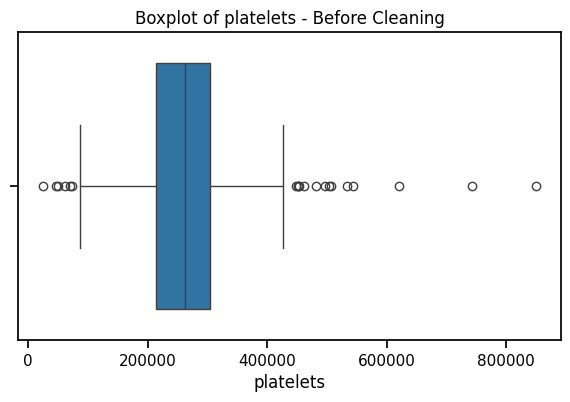

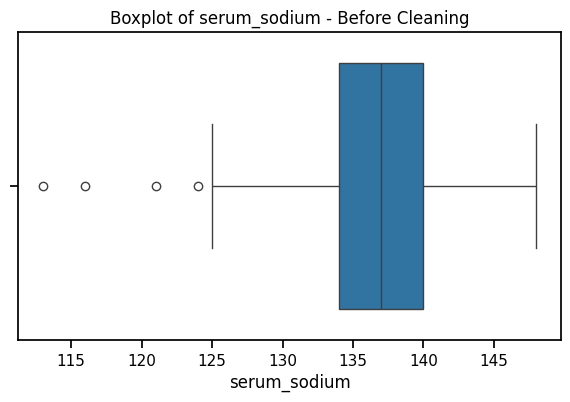

In [8]:
for feature in selected_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature} - Before Cleaning")
    plt.xlabel(feature)
    plt.show()


## 8. Summary Statistics Before Cleaning

In [9]:
before_stats = pd.DataFrame({
    "Mean": df[selected_features].mean(),
    "Median": df[selected_features].median(),
    "Std Dev": df[selected_features].std(),
    "Minimum": df[selected_features].min(),
    "Maximum": df[selected_features].max()
})

display(before_stats.round(4))


,Mean,Median,Std Dev,Minimum,Maximum
age,60.8339,60.000,11.8948,40.0,95.0
ejection_fraction,38.0836,38.000,11.8348,14.0,80.0
serum_creatinine,1.3678,1.100,0.9291,0.5,9.0
platelets,264553.3766,263179.015,97658.0380,25100.0,850000.0
serum_sodium,136.6254,137.000,4.4125,113.0,148.0


## 9. Impute Missing Values

### Strategy
- **Numerical features:** median imputation is used because medical measurements can be skewed and affected by extreme values.
- **Categorical/binary features:** mode imputation is used.


In [10]:
# Numerical imputation
numerical_impute_cols = ["serum_creatinine", "platelets"]

for col in numerical_impute_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: filled missing values with median = {median_value}")

# Categorical/binary imputation
categorical_impute_cols = ["smoking"]

for col in categorical_impute_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"{col}: filled missing values with mode = {mode_value}")

print("\nMissing values after imputation:")
display(df.isnull().sum().to_frame("Missing Values"))


serum_creatinine: filled missing values with median = 1.1
platelets: filled missing values with median = 263179.015
smoking: filled missing values with mode = 0.0

Missing values after imputation:


,Missing Values
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


## 10. Correct Inconsistencies

The assignment specifically suggests checking invalid entries such as negative age.  
We therefore validate important clinical ranges and repair invalid values if any are found.


In [11]:
print("Rows with invalid negative age:", (df["age"] < 0).sum())
print("Rows with non-positive ejection fraction:", (df["ejection_fraction"] <= 0).sum())
print("Rows with non-positive serum creatinine:", (df["serum_creatinine"] <= 0).sum())
print("Rows with non-positive platelets:", (df["platelets"] <= 0).sum())

# Fix invalid values if any occur.
# Replace invalid continuous values with NaN, then impute using median.
range_checks = {
    "age": lambda s: s < 0,
    "ejection_fraction": lambda s: s <= 0,
    "serum_creatinine": lambda s: s <= 0,
    "platelets": lambda s: s <= 0
}

for col, invalid_rule in range_checks.items():
    invalid_mask = invalid_rule(df[col])
    if invalid_mask.any():
        print(f"Correcting {invalid_mask.sum()} invalid value(s) in {col}")
        df.loc[invalid_mask, col] = np.nan
        df[col] = df[col].fillna(df[col].median())

print("\nInconsistency checks completed.")


Rows with invalid negative age: 0
Rows with non-positive ejection fraction: 0
Rows with non-positive serum creatinine: 0
Rows with non-positive platelets: 0

Inconsistency checks completed.


## 11. Remove Outliers Using the IQR Method

Outliers are detected only on continuous clinical measurements.  
Binary variables such as `anaemia`, `diabetes`, `sex`, and `smoking` are not treated as outliers.

The IQR rule is:

- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR


In [12]:
continuous_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

outlier_summary = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(count)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df.round(4))


,Feature,Lower Bound,Upper Bound,Outlier Count
0,age,22.50,98.50,0
1,creatinine_phosphokinase,-581.75,1280.25,29
2,ejection_fraction,7.50,67.50,2
3,platelets,82250.00,436250.00,20
4,serum_creatinine,0.15,2.15,27
5,serum_sodium,125.00,149.00,4
6,time,-122.00,398.00,0


### Outlier-handling decision
Instead of removing a row just because one clinical measurement is extreme, this notebook removes rows only when they violate the IQR range for one or more selected continuous measurements. This follows the assignment's explicit instruction to remove outliers.


In [13]:
df_no_outliers = df.copy()
keep_mask = pd.Series(True, index=df_no_outliers.index)

for col in continuous_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    keep_mask &= df_no_outliers[col].between(lower, upper)

rows_before = len(df_no_outliers)
df_clean = df_no_outliers.loc[keep_mask].reset_index(drop=True)
rows_after = len(df_clean)

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_before - rows_after)


Rows before outlier removal: 299
Rows after outlier removal: 225
Rows removed: 74


## 12. Feature Engineering

### 12.1 Create `age_group`

In [14]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

display(df_clean[["age", "age_group"]].head(10))
print("\nAge-group counts:")
display(df_clean["age_group"].value_counts().sort_index().to_frame("Count"))


,age,age_group
0,75.0,>60
1,65.0,>60
2,50.0,40-60
3,90.0,>60
4,75.0,>60
5,65.0,>60
6,80.0,>60
7,62.0,>60
8,45.0,40-60
9,50.0,40-60



Age-group counts:


,Count
age_group,
<40,0
40-60,99
>60,126


### 12.2 Create `risk_score`

The assignment suggests a risk score based on the **normalized product of ejection fraction and serum creatinine**.

To follow that requirement directly:
1. Normalize both variables to 0-1.
2. Multiply the normalized values.
3. Store the result as `risk_score`.

This is an assignment feature-engineering example, not a validated clinical risk score.


In [15]:
risk_scaler = MinMaxScaler()

risk_components = risk_scaler.fit_transform(
    df_clean[["ejection_fraction", "serum_creatinine"]]
)

ef_norm = risk_components[:, 0]
creatinine_norm = risk_components[:, 1]

df_clean["risk_score"] = ef_norm * creatinine_norm

display(
    df_clean[
        ["ejection_fraction", "serum_creatinine", "risk_score"]
    ].head(10)
)


,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.101961
1,20,1.3,0.054902
2,20,1.9,0.101961
3,40,2.1,0.509804
4,15,1.2,0.007843
5,65,1.5,0.600000
6,35,1.1,0.137255
7,25,0.9,0.043137
8,30,1.1,0.104575
9,38,1.1,0.156863


## 13. Encode Categorical Variables

The binary variables `sex` and `smoking` are categorical in meaning.  
For this assignment, one-hot encoding is applied using `pandas.get_dummies()`.

The engineered `age_group` feature is also encoded.


In [16]:
categorical_cols = ["sex", "smoking", "age_group"]

df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_cols,
    prefix=categorical_cols,
    drop_first=False,
    dtype=int
)

print("Shape before encoding:", df_clean.shape)
print("Shape after encoding:", df_encoded.shape)

display(df_encoded.head())


Shape before encoding: (225, 15)
Shape after encoding: (225, 19)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_0,sex_1,smoking_0.0,smoking_1.0,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,4,1,0.101961,0,1,1,0,0,0,1
1,65.0,0,146,0,20,0,162000.0,1.3,129,7,1,0.054902,0,1,0,1,0,0,1
2,50.0,1,111,0,20,0,210000.0,1.9,137,7,1,0.101961,0,1,1,0,0,1,0
3,90.0,1,47,0,40,1,204000.0,2.1,132,8,1,0.509804,0,1,0,1,0,0,1
4,75.0,1,246,0,15,0,127000.0,1.2,137,10,1,0.007843,0,1,1,0,0,0,1


## 14. Normalize Numerical Features to 0-1

`MinMaxScaler` transforms selected numerical features to the range 0-1:

\[
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
\]


In [17]:
scale_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

scaler = MinMaxScaler()

df_scaled = df_encoded.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

print("Scaled numerical feature ranges:")

range_table = pd.DataFrame({
    "Minimum": df_scaled[scale_cols].min(),
    "Maximum": df_scaled[scale_cols].max()
})

display(range_table.round(4))


Scaled numerical feature ranges:


,Minimum,Maximum
age,0.0,1.0
creatinine_phosphokinase,0.0,1.0
ejection_fraction,0.0,1.0
platelets,0.0,1.0
serum_creatinine,0.0,1.0
serum_sodium,0.0,1.0
time,0.0,1.0


## 15. Summary Statistics After Cleaning

In [18]:
after_stats = pd.DataFrame({
    "Mean": df_clean[selected_features].mean(),
    "Median": df_clean[selected_features].median(),
    "Std Dev": df_clean[selected_features].std(),
    "Minimum": df_clean[selected_features].min(),
    "Maximum": df_clean[selected_features].max()
})

display(after_stats.round(4))


,Mean,Median,Std Dev,Minimum,Maximum
age,60.8948,60.000,11.9879,40.0,95.0
ejection_fraction,38.1644,38.000,11.6866,14.0,65.0
serum_creatinine,1.1307,1.100,0.3254,0.6,2.1
platelets,257097.6959,263179.015,66980.1088,126000.0,427000.0
serum_sodium,137.0267,137.000,3.8078,125.0,148.0


### Before vs After Cleaning

In [19]:
comparison = pd.concat(
    {
        "Before Cleaning": before_stats,
        "After Cleaning": after_stats
    },
    axis=1
)

display(comparison.round(4))


Before Cleaning                                             \
                             Mean      Median     Std Dev  Minimum   Maximum   
age                       60.8339      60.000     11.8948     40.0      95.0   
ejection_fraction         38.0836      38.000     11.8348     14.0      80.0   
serum_creatinine           1.3678       1.100      0.9291      0.5       9.0   
platelets             264553.3766  263179.015  97658.0380  25100.0  850000.0   
serum_sodium             136.6254     137.000      4.4125    113.0     148.0   

                  After Cleaning                                              
                            Mean      Median     Std Dev   Minimum   Maximum  
age                      60.8948      60.000     11.9879      40.0      95.0  
ejection_fraction        38.1644      38.000     11.6866      14.0      65.0  
serum_creatinine          1.1307       1.100      0.3254       0.6       2.1  
platelets            257097.6959  263179.015  66980.1088  126000.0  427000.0  
serum_sodium            137.0267     137.000      3.8078     125.0     148.0

## 16. Validate Cleaning with Histograms

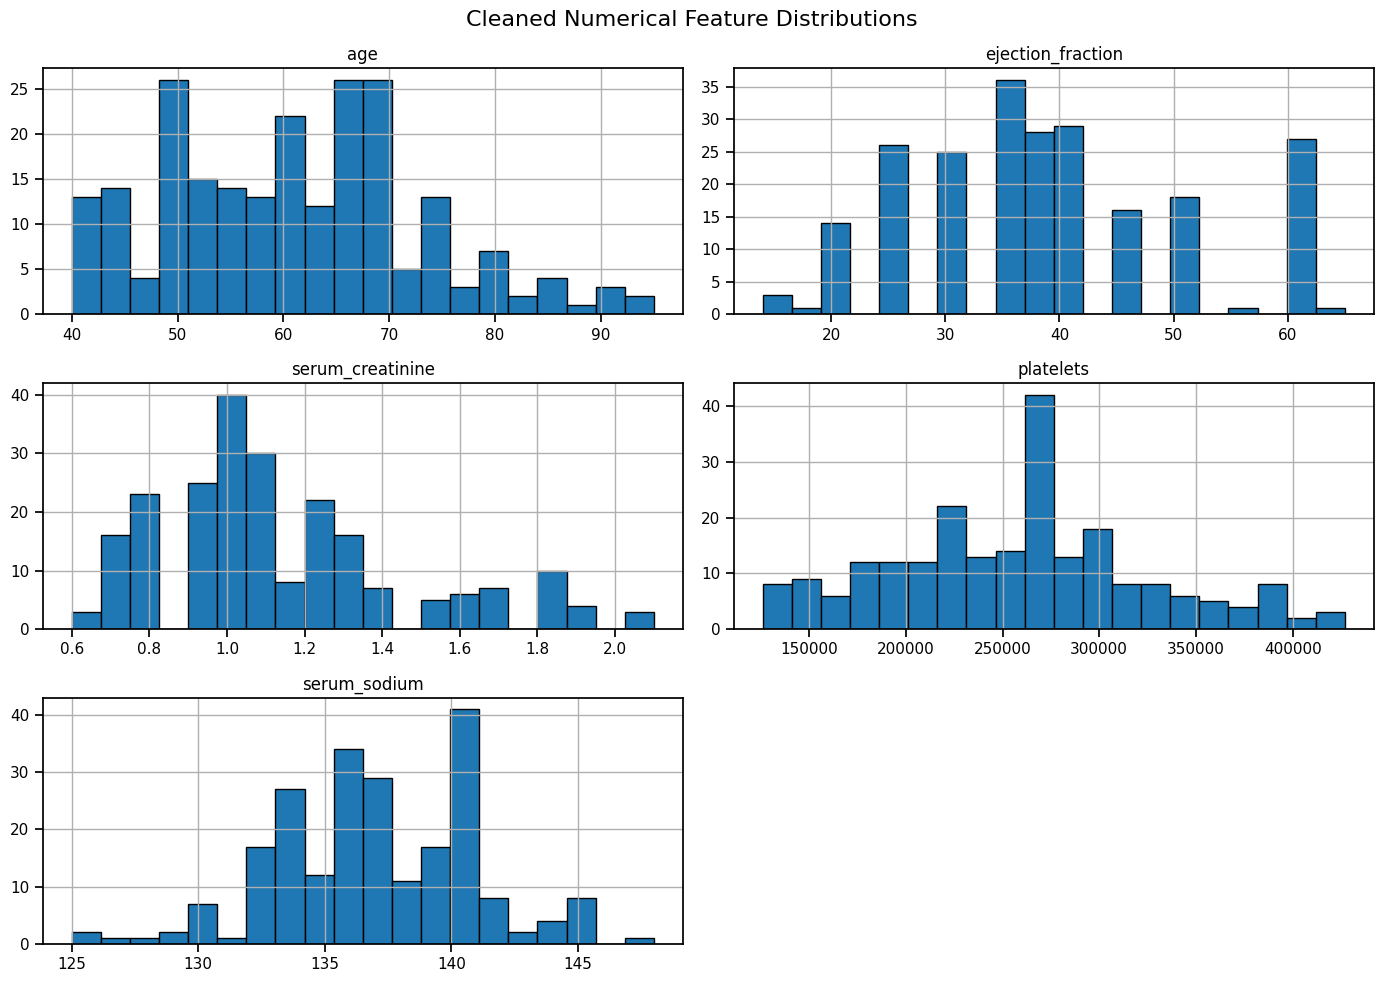

In [20]:
df_clean[selected_features].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)
plt.suptitle("Cleaned Numerical Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


## 17. Validate Cleaning with Boxplots

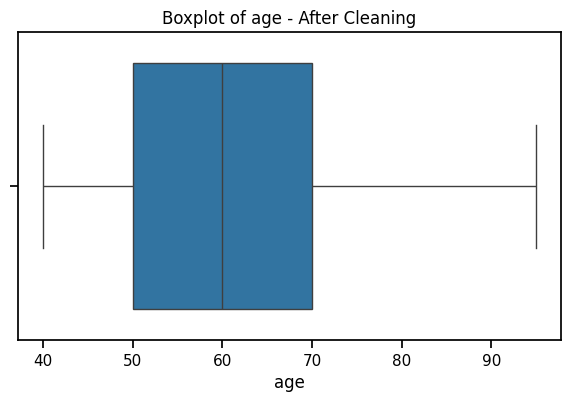

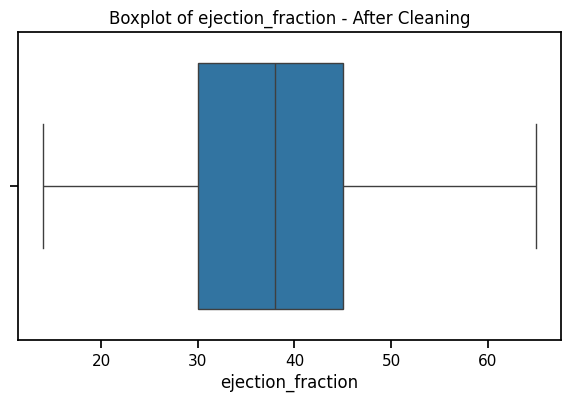

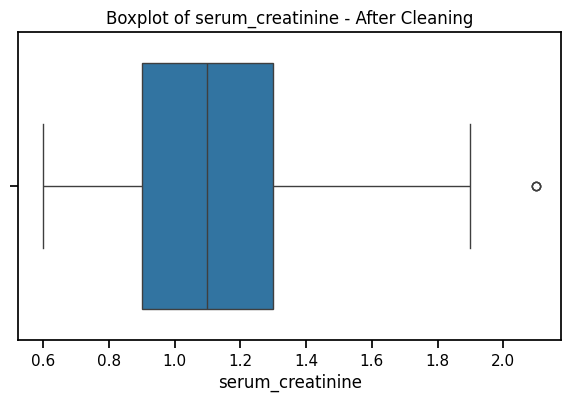

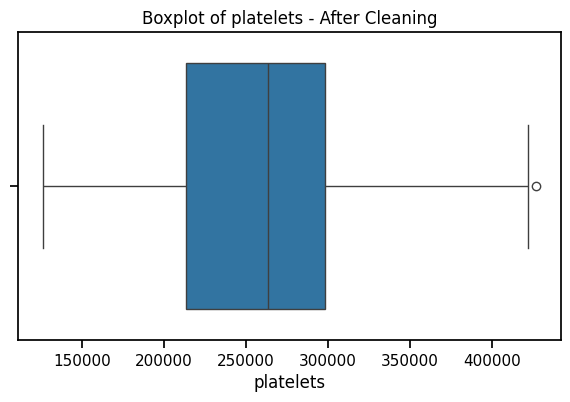

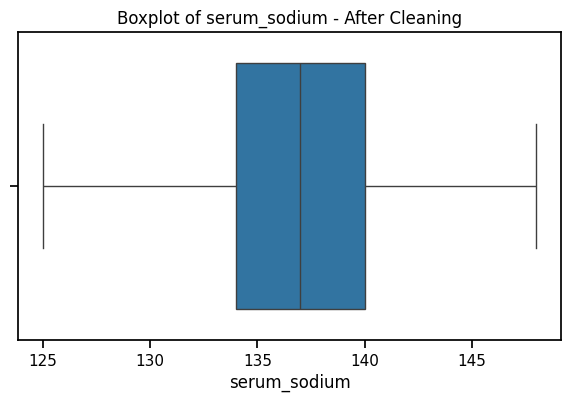

In [21]:
for feature in selected_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df_clean[feature])
    plt.title(f"Boxplot of {feature} - After Cleaning")
    plt.xlabel(feature)
    plt.show()


## 18. Final Missing-Value Check

In [22]:
final_missing = df_scaled.isnull().sum()
remaining_missing = final_missing[final_missing > 0]

if len(remaining_missing) == 0:
    print("Validation successful: no missing values remain.")
else:
    print("Some missing values remain:")
    display(remaining_missing.to_frame("Missing Values"))

print("\nTotal remaining missing values:", int(df_scaled.isnull().sum().sum()))


Validation successful: no missing values remain.

Total remaining missing values: 0


## 19. Final Dataset Summary

In [23]:
print("Original dataset shape:", df_original.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Encoded + normalized dataset shape:", df_scaled.shape)

print("\nFinal columns:")
print(list(df_scaled.columns))

display(df_scaled.head())


Original dataset shape: (299, 13)
Cleaned dataset shape: (225, 15)
Encoded + normalized dataset shape: (225, 19)

Final columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'time', 'DEATH_EVENT', 'risk_score', 'sex_0', 'sex_1', 'smoking_0.0', 'smoking_1.0', 'age_group_<40', 'age_group_40-60', 'age_group_>60']


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_0,sex_1,smoking_0.0,smoking_1.0,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.461794,0.866667,0.217391,0.000000,1,0.101961,0,1,1,0,0,0,1
1,0.454545,0,0.098976,0,0.117647,0,0.119601,0.466667,0.173913,0.010676,1,0.054902,0,1,0,1,0,0,1
2,0.181818,1,0.069113,0,0.117647,0,0.279070,0.866667,0.521739,0.010676,1,0.101961,0,1,1,0,0,1,0
3,0.909091,1,0.014505,0,0.509804,1,0.259136,1.000000,0.304348,0.014235,1,0.509804,0,1,0,1,0,0,1
4,0.636364,1,0.184300,0,0.019608,0,0.003322,0.400000,0.521739,0.021352,1,0.007843,0,1,1,0,0,0,1


## 20. Conclusion

The Heart Failure Clinical Records dataset was successfully loaded and processed in Google Colab.

The workflow included:

- dataset acquisition and inspection,
- missing-value visualization,
- controlled demonstration of missing-value imputation,
- distribution analysis,
- inconsistency checks,
- IQR-based outlier removal,
- `age_group` and `risk_score` feature engineering,
- categorical encoding,
- MinMax normalization,
- comparison of summary statistics before and after cleaning,
- validation using histograms and boxplots,
- and confirmation that no missing values remain.

The final cleaned and enriched dataset is suitable for downstream machine-learning experiments.
